### CREATING A SHOTMAP OF KYLIAN MBAPPE, UCL - 2025/26

In [96]:
# Group stage - match ID filtering
from sofascoreapi import League
from sofascoreapi import _fetch, BASE_URL

UCL_ID    = "7"
SEASON_ID = "76953"
RM_ID     = 2829

matches = []
round_n = 1

while True:
    try:
        data   = _fetch(f"{BASE_URL}/unique-tournament/{UCL_ID}/season/{SEASON_ID}/events/round/{round_n}")
        events = data.get("events", [])
        if not events:
            break
        for ev in events:
            home_id = ev["homeTeam"]["id"]
            away_id = ev["awayTeam"]["id"]
            status  = ev["status"]["type"]
            if RM_ID in (home_id, away_id) and status == "finished":
                matches.append({
                    "match_id": str(ev["id"]),
                    "round":    round_n,
                    "home":     ev["homeTeam"]["name"],
                    "away":     ev["awayTeam"]["name"],
                })
        round_n += 1
    except Exception:
        break

for m in matches:
    print(m["round"], m["match_id"], m["home"], "vs", m["away"])

print(f"\nTotal: {len(matches)} matches")

1 14566597 Real Madrid vs Olympique de Marseille
2 14566983 Kairat Almaty vs Real Madrid
3 14566596 Real Madrid vs Juventus
4 14566636 Liverpool FC vs Real Madrid
5 14566865 Olympiacos FC vs Real Madrid
6 14566595 Real Madrid vs Manchester City
7 14566598 Real Madrid vs AS Monaco
8 14566735 Benfica vs Real Madrid

Total: 8 matches


In [97]:
# Knockout matches via team event history
from sofascoreapi import _fetch, BASE_URL

RM_ID     = 2829
UCL_ID    = "7"
SEASON_ID = "76953"

# Sofascore team events endpoint — paginated
page = 0
ko_matches = []

while True:
    try:
        data   = _fetch(f"{BASE_URL}/team/{RM_ID}/events/last/{page}")
        events = data.get("events", [])
        if not events:
            break
        for ev in events:
            tid = ev.get("tournament", {}).get("uniqueTournament", {}).get("id")
            sid = ev.get("season", {}).get("id")
            status = ev.get("status", {}).get("type", "")
            if str(tid) == UCL_ID and str(sid) == SEASON_ID and status == "finished":
                home = ev["homeTeam"]["name"]
                away = ev["awayTeam"]["name"]
                mid  = str(ev["id"])
                if not any(m["match_id"] == mid for m in matches):
                    ko_matches.append({"match_id": mid, "home": home, "away": away})
                    print(mid, home, "vs", away)
        page += 1
    except Exception:
        break

print(f"\nKnockout matches found: {len(ko_matches)}")

15452742 Benfica vs Real Madrid
15452752 Real Madrid vs Benfica
15631329 Real Madrid vs Manchester City
15631365 Manchester City vs Real Madrid
15632084 Real Madrid vs FC Bayern München
15632088 FC Bayern München vs Real Madrid

Knockout matches found: 6


In [3]:
from sofascoreapi import MatchStats, Team

# 1. Get Mbappé ID
rm_squad = Team("2829").get_squad()
mbappe_id = None
for player_entry in rm_squad["players"]:
    player = player_entry["player"]
    if player["name"].lower() == "kylian mbappé":
        mbappe_id = player["id"]
        break

print(f"Mbappé player ID: {mbappe_id}")

# 2. All match IDs
group_stage = [
    {"round": 1, "match_id": "14566597", "home": "Real Madrid", "away": "Olympique de Marseille"},
    {"round": 2, "match_id": "14566983", "home": "Kairat Almaty", "away": "Real Madrid"},
    {"round": 3, "match_id": "14566596", "home": "Real Madrid", "away": "Juventus"},
    {"round": 4, "match_id": "14566636", "home": "Liverpool FC", "away": "Real Madrid"},
    {"round": 5, "match_id": "14566865", "home": "Olympiacos FC", "away": "Real Madrid"},
    {"round": 6, "match_id": "14566595", "home": "Real Madrid", "away": "Manchester City"},
    {"round": 7, "match_id": "14566598", "home": "Real Madrid", "away": "AS Monaco"},
    {"round": 8, "match_id": "14566735", "home": "Benfica", "away": "Real Madrid"},
]

knockout = [
    {"match_id": "15452742", "home": "Benfica", "away": "Real Madrid"},
    {"match_id": "15452752", "home": "Real Madrid", "away": "Benfica"},
    {"match_id": "15631329", "home": "Real Madrid", "away": "Manchester City"},
    {"match_id": "15631365", "home": "Manchester City", "away": "Real Madrid"},
    {"match_id": "15632084", "home": "Real Madrid", "away": "FC Bayern München"},
    {"match_id": "15632088", "home": "FC Bayern München", "away": "Real Madrid"},
]

all_matches = group_stage + knockout

# 3. Extract Mbappé's shots 
mbappe_shots = []

for match_info in all_matches:
    match_id = match_info["match_id"]
    try:
        shot_data = MatchStats(match_id).get_shotmap()
        shots = shot_data.get("shotmap", [])
        for s in shots:
            if s.get("player", {}).get("id") != mbappe_id:
                continue

            # Coordinates from the nested 'playerCoordinates' dict
            coord = s.get("playerCoordinates", {})
            x = coord.get("x")
            y = coord.get("y")
            goal_mouth = s.get("goalMouthCoordinates", {})

            mbappe_shots.append({
                "match_id": match_id,
                "home_team": match_info["home"],
                "away_team": match_info["away"],
                "round": match_info.get("round", "KO"),
                "x": x,
                "y": y,
                "xg": s.get("xg"),
                "shotType": s.get("shotType"),        # 'goal', 'saved', 'block', 'miss', etc.
                "bodyPart": s.get("bodyPart"),
                "situation": s.get("situation"),      # 'openPlay', 'corner', 'freeKick', etc.
                "goalMouthLocation": s.get("goalMouthLocation"),
                "goal_mouth_y":      goal_mouth.get("y", 50),
                "time_min": s.get("time"),            # minute of the match
            })
    except Exception as e:
        print(f"  ⚠ Skipping match {match_id}: {e}")

print(f"\nTotal Mbappé shots across all UCL matches: {len(mbappe_shots)}")

# Quick preview
import json
print(json.dumps(mbappe_shots[:3], indent=2, ensure_ascii=False))

Mbappé player ID: 826643

Total Mbappé shots across all UCL matches: 56
[
  {
    "match_id": "14566597",
    "home_team": "Real Madrid",
    "away_team": "Olympique de Marseille",
    "round": 1,
    "x": 11.5,
    "y": 50,
    "xg": 0.7884,
    "shotType": "goal",
    "bodyPart": "right-foot",
    "situation": "penalty",
    "goalMouthLocation": "low-left",
    "goal_mouth_y": 54.1,
    "time_min": 81
  },
  {
    "match_id": "14566597",
    "home_team": "Real Madrid",
    "away_team": "Olympique de Marseille",
    "round": 1,
    "x": 18.1,
    "y": 48.3,
    "xg": 0.065698057413101,
    "shotType": "miss",
    "bodyPart": "right-foot",
    "situation": "assisted",
    "goalMouthLocation": "left",
    "goal_mouth_y": 70.3,
    "time_min": 76
  },
  {
    "match_id": "14566597",
    "home_team": "Real Madrid",
    "away_team": "Olympique de Marseille",
    "round": 1,
    "x": 11.1,
    "y": 57,
    "xg": 0.090162381529808,
    "shotType": "block",
    "bodyPart": "left-foot",
    "s

In [4]:
# Show first 2 shots with ALL keys (deep dive)
for i, shot in enumerate(mbappe_shots[:10]):
    print(f"\n{'='*50}\nShot {i+1}\n{'='*50}")
    print(json.dumps(shot, indent=2, ensure_ascii=False))


Shot 1
{
  "match_id": "14566597",
  "home_team": "Real Madrid",
  "away_team": "Olympique de Marseille",
  "round": 1,
  "x": 11.5,
  "y": 50,
  "xg": 0.7884,
  "shotType": "goal",
  "bodyPart": "right-foot",
  "situation": "penalty",
  "goalMouthLocation": "low-left",
  "goal_mouth_y": 54.1,
  "time_min": 81
}

Shot 2
{
  "match_id": "14566597",
  "home_team": "Real Madrid",
  "away_team": "Olympique de Marseille",
  "round": 1,
  "x": 18.1,
  "y": 48.3,
  "xg": 0.065698057413101,
  "shotType": "miss",
  "bodyPart": "right-foot",
  "situation": "assisted",
  "goalMouthLocation": "left",
  "goal_mouth_y": 70.3,
  "time_min": 76
}

Shot 3
{
  "match_id": "14566597",
  "home_team": "Real Madrid",
  "away_team": "Olympique de Marseille",
  "round": 1,
  "x": 11.1,
  "y": 57,
  "xg": 0.090162381529808,
  "shotType": "block",
  "bodyPart": "left-foot",
  "situation": "assisted",
  "goalMouthLocation": "low-centre",
  "goal_mouth_y": 48.7,
  "time_min": 54
}

Shot 4
{
  "match_id": "145665

In [5]:
# converting parsed JSON into dataframe
import pandas as pd

# 1. Create DataFrame from the list of dicts
df = pd.DataFrame(mbappe_shots)

# 2. Reorder and keep the most useful columns
columns_to_keep = [
    'match_id', 'round', 'home_team', 'away_team',
    'x', 'y', 'xg', 'shotType', 'bodyPart', 'situation',
    'goalMouthLocation', 'goal_mouth_y', 'time_min'
]
df = df[columns_to_keep].copy()

# 3. Rename for clarity (optional)
df.rename(columns={
    'shotType': 'result',
    'time_min': 'minute',
    'bodyPart': 'body_part',
    'goalMouthLocation': 'target_zone'
}, inplace=True)

# 4. Drop rows with missing essential coordinates (if any)
df = df.dropna(subset=['x', 'y'])
df

,match_id,round,home_team,away_team,x,y,xg,result,body_part,situation,target_zone,goal_mouth_y,minute
0,14566597,1,Real Madrid,Olympique de Marseille,11.5,50.0,0.788400,goal,right-foot,penalty,low-left,54.1,81
1,14566597,1,Real Madrid,Olympique de Marseille,18.1,48.3,0.065698,miss,right-foot,assisted,left,70.3,76
2,14566597,1,Real Madrid,Olympique de Marseille,11.1,57.0,0.090162,block,left-foot,assisted,low-centre,48.7,54
3,14566597,1,Real Madrid,Olympique de Marseille,19.1,29.9,0.013419,block,right-foot,corner,low-centre,49.6,50
4,14566597,1,Real Madrid,Olympique de Marseille,16.3,46.0,0.144209,save,right-foot,assisted,low-left,52.7,41
5,14566597,1,Real Madrid,Olympique de Marseille,10.2,31.3,0.043940,block,right-foot,assisted,low-centre,51.3,33
6,14566597,1,Real Madrid,Olympique de Marseille,11.5,50.0,0.788400,goal,right-foot,penalty,low-left,53.1,29
7,14566597,1,Real Madrid,Olympique de Marseille,5.2,71.6,0.033376,save,right-foot,throw-in-set-piece,low-centre,51.5,21
8,14566597,1,Real Madrid,Olympique de Marseille,10.5,41.9,0.093102,save,left-foot,assisted,high-centre,51.6,10
9,14566597,1,Real Madrid,Olympique de Marseille,8.6,42.5,0.181525,miss,right-foot,regular,close-right,41.7,2


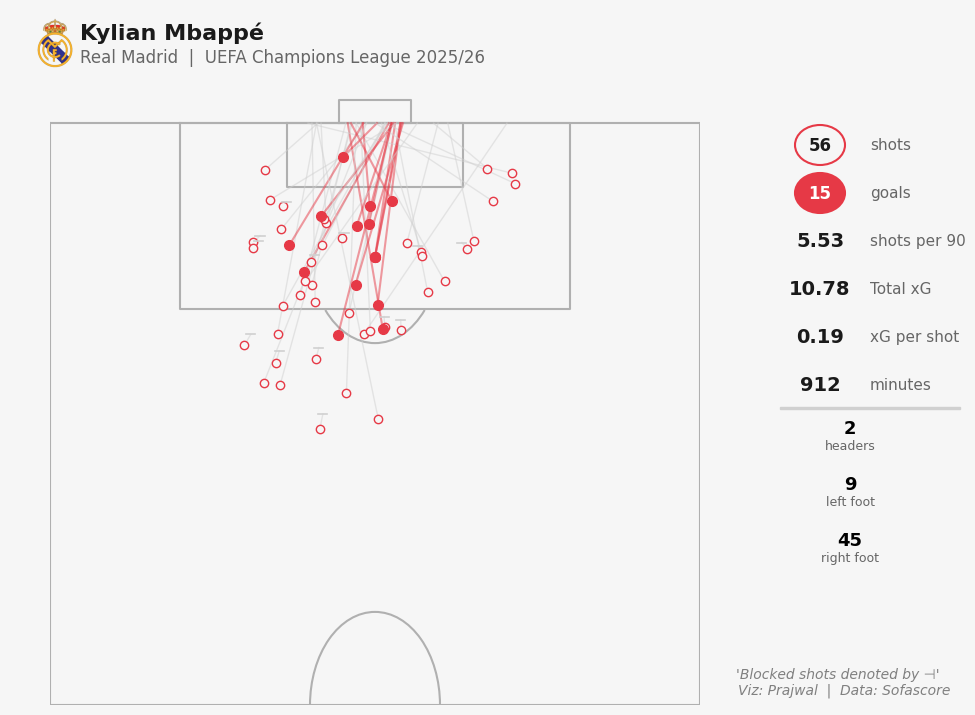

In [107]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
import numpy as np

# --- Calculations ---
total_shots  = len(df)
goals        = len(df[df['result'] == 'goal'])
total_min    = 912
shots_per_90 = (total_shots / total_min) * 90
total_xg     = df['xg'].sum()
xg_per_shot  = total_xg / total_shots
headers      = len(df[df['body_part'] == 'head'])
left_foot    = len(df[df['body_part'] == 'left-foot'])
right_foot   = len(df[df['body_part'] == 'right-foot'])

# --- Figure ---
fig = plt.figure(figsize=(10, 8), facecolor='#F6F6F6')
ax  = fig.add_axes([0.05, 0.05, 0.65, 0.8])
ax.set_facecolor('#F6F6F6')
ax.set_xlim(0, 100)
ax.set_ylim(50, -5)
ax.axis('off')


# --- Pitch Lines ---
pitch_color = '#B0B0B0'
ax.plot([0, 100, 100, 0, 0],               [0, 0, 50, 50, 0],   color=pitch_color, lw=1.5)
ax.plot([20, 80, 80, 20, 20],              [0, 0, 16, 16, 0],   color=pitch_color, lw=1.5)
ax.plot([36.5, 63.5, 63.5, 36.5, 36.5],   [0, 0, 5.5, 5.5, 0], color=pitch_color, lw=1.5)
ax.plot([44.5, 55.5, 55.5, 44.5, 44.5],   [0, 0, -2, -2, 0],   color=pitch_color, lw=1.5)
ax.plot(50, 11.5, 'o', color=pitch_color, markersize=3)

# D-arc: only draw segment outside penalty box
# Arc center (50,11.5), height=16 → crosses box line y=16 at sin(θ)=4.5/8=0.5625 → θ≈34° and 146°
arc = patches.Arc((50, 10.9), 20, 16, theta1=34, theta2=146, color=pitch_color, lw=1.5)
ax.add_patch(arc)

# Centre circle half
arc_center = patches.Arc((50, 50), 20, 16, theta1=180, theta2=360, color=pitch_color, lw=1.5)
ax.add_patch(arc_center)

# --- Plot Shots ---
for i, row in df.iterrows():
    x, y    = row['x'], row['y']
    is_goal = row['result'] == 'goal'
    is_blocked = row['result'] == 'block'

    if is_goal:
        ax.plot([y, row['goal_mouth_y']], [x, 0], color='#E63946', alpha=0.5, lw=1.5, zorder=2)
        ax.plot(y, x, 'o', color='#E63946', markeredgecolor='#E63946', markersize=7, zorder=5)

    elif is_blocked:
        t     = 0.05
        end_y = y + t * (row['goal_mouth_y'] - y)
        end_x = x * (1 - t)
        ax.plot([y, end_y], [x, end_x], color='#D0D0D0', alpha=0.5, lw=1, zorder=2)
        ax.plot(y, x, 'o', color='#F6F6F6', markeredgecolor='#E63946', markersize=6, lw=1.5, zorder=4)
        ax.plot([end_y - 0.7, end_y + 0.7], [end_x, end_x], color='#D0D0D0', lw=1.2, zorder=7)

    else:
         ax.plot([y, row['goal_mouth_y']], [x, 0], color='#D0D0D0', alpha=0.5, lw=1, zorder=2)
         ax.plot(y, x, 'o', color='#F6F6F6', markeredgecolor='#E63946', markersize=6, lw=1.5, zorder=4)
        
# --- Title ---
fig.text(0.08, 0.89, "Kylian Mbappé",
         fontsize=16, fontweight='bold', va='center', color='#1A1A1A')
fig.text(0.08, 0.86, "Real Madrid  |  UEFA Champions League 2025/26",
         fontsize=12, color='#666666', va='center')

# --- Logo ---
from PIL import Image
import numpy as np

img  = Image.open('rm_logo.PNG').convert('RGBA')
data = np.array(img)
white = (data[:,:,0] > 200) & (data[:,:,1] > 200) & (data[:,:,2] > 200)
data[white, 3] = 0

logo_ax = fig.add_axes([0.01, 0.835, 0.09, 0.085])
logo_ax.imshow(Image.fromarray(data))
logo_ax.axis('off')

# --- Stats Panel ---
cx       = 0.82
cx_label = 0.87
start_y  = 0.75
gap      = 0.06

def add_stat(val, label, y_pos, highlight=False, is_circle=False):
    if is_circle:
        circle = patches.Circle((cx, y_pos), 0.025, transform=fig.transFigure,
                                 facecolor='#E63946' if highlight else 'none',
                                 edgecolor='#E63946', lw=1.5)
        fig.patches.append(circle)
        fig.text(cx, y_pos, val, fontsize=12, fontweight='bold',
                 color='white' if highlight else '#1A1A1A',
                 ha='center', va='center')
    else:
        fig.text(cx, y_pos, val, fontsize=14, fontweight='bold',
                 color='#1A1A1A', ha='center', va='center')
    fig.text(cx_label, y_pos, label, fontsize=11, color='#666666', ha='left', va='center')

# ← fix: is_circle=True restores the outline circle around shots
add_stat(str(total_shots),      "shots",        start_y,           is_circle=True)
add_stat(str(goals),            "goals",        start_y - gap,     highlight=True, is_circle=True)
add_stat(f"{shots_per_90:.2f}", "shots per 90", start_y - 2*gap)
add_stat(f"{total_xg:.2f}",     "Total xG",     start_y - 3*gap)
add_stat(f"{xg_per_shot:.2f}",  "xG per shot",  start_y - 4*gap)
add_stat(str(total_min),        "minutes",      start_y - 5*gap)

# Separator
fig.add_artist(patches.Rectangle(
    (cx - 0.04, start_y - 5.5*gap), 0.18, 0.002,
    color='#D0D0D0', transform=fig.transFigure
))

# Body Parts
bp_y = start_y - 6*gap
fig.text(cx + 0.03, bp_y,        str(headers),    fontsize=13, fontweight='bold', ha='center')
fig.text(cx + 0.03, bp_y - 0.02, "headers",       fontsize=9,  color='#666666',  ha='center')
fig.text(cx + 0.03, bp_y - 0.07, str(left_foot),  fontsize=13, fontweight='bold', ha='center')
fig.text(cx + 0.03, bp_y - 0.09, "left foot",     fontsize=9,  color='#666666',  ha='center')
fig.text(cx + 0.03, bp_y - 0.14, str(right_foot), fontsize=13, fontweight='bold', ha='center')
fig.text(cx + 0.03, bp_y - 0.16, "right foot",    fontsize=9,  color='#666666',  ha='center')

# Credit
fig.text(0.95, 0.06, "Viz: Prajwal  |  Data: Sofascore",
         fontsize=10, color='#808080', ha='right', va='bottom', style='italic')

fig.text(0.94, 0.08, "'Blocked shots denoted by ⊣'",
         fontsize=10, color='#808080', ha='right', va='bottom', style='italic')

plt.savefig("mbappe_ucl_shotmap.png", dpi=200, bbox_inches='tight', facecolor='#F6F6F6')
plt.show()

In [24]:
print(df['result'].value_counts())

result
goal     15
save     15
miss     13
block    13
Name: count, dtype: int64


In [48]:
import matplotlib.image as mpimg
import os

print(os.getcwd())                        # shows current directory
print(os.path.exists('rm_logo.PNG'))      # True or False

/home/prajwal/Python Projects/Python_Data_visualization Project/Football Data Analytics/Sofascore
True


In [50]:
with open('rm_logo.PNG', 'rb') as f:
    print(f.read(10))  # reads first 10 bytes - reveals true format

b'RIFF\xf2-\x00\x00WE'
